# Convolutional Neural Networks

## Preliminaries

In this practical session you will implement and train several Convolutional Neural Networks (CNNs) using the Keras framework with a Tensorflow backend. If you are not already familiar with Keras, you can go over the [following tutorial](https://github.com/tueimage/essential-skills/blob/master/keras.md). More detailed information on the different functionalities can be found in the [Keras library documentation](https://keras.io/). 

Note that for this set of exercise CPU-only Tensorflow, which you should already have installed, is sufficient (i.e. GPU-support is not required but it will make your experiments run faster). 

You are also required to use the `gryds` package for data augmentation that you can install directly from git: `pip install git+https://github.com/tueimage/gryds/`.

You also have to install the Keras deep learning framework (if you have not done so already) by running `conda install keras`. Note that there are two implementations of Keras, one from https://keras.io/ and another one that ships with Tensorflow. Here we use the former. 

## MNIST
We will first train a simple CNN to classify handwritten digits using the MNIST dataset. This dataset is often referred to as the "Hello world!" example of deep learning because it can be used to quickly illustrate a small neural network in action (and obtain a decent classification accuracy in the process). More information on it can be found [here](http://yann.lecun.com/exdb/mnist/).

First, let's load the dataset and visualize some images.

11490434/11490434 [==============================] - 1s 0us/step


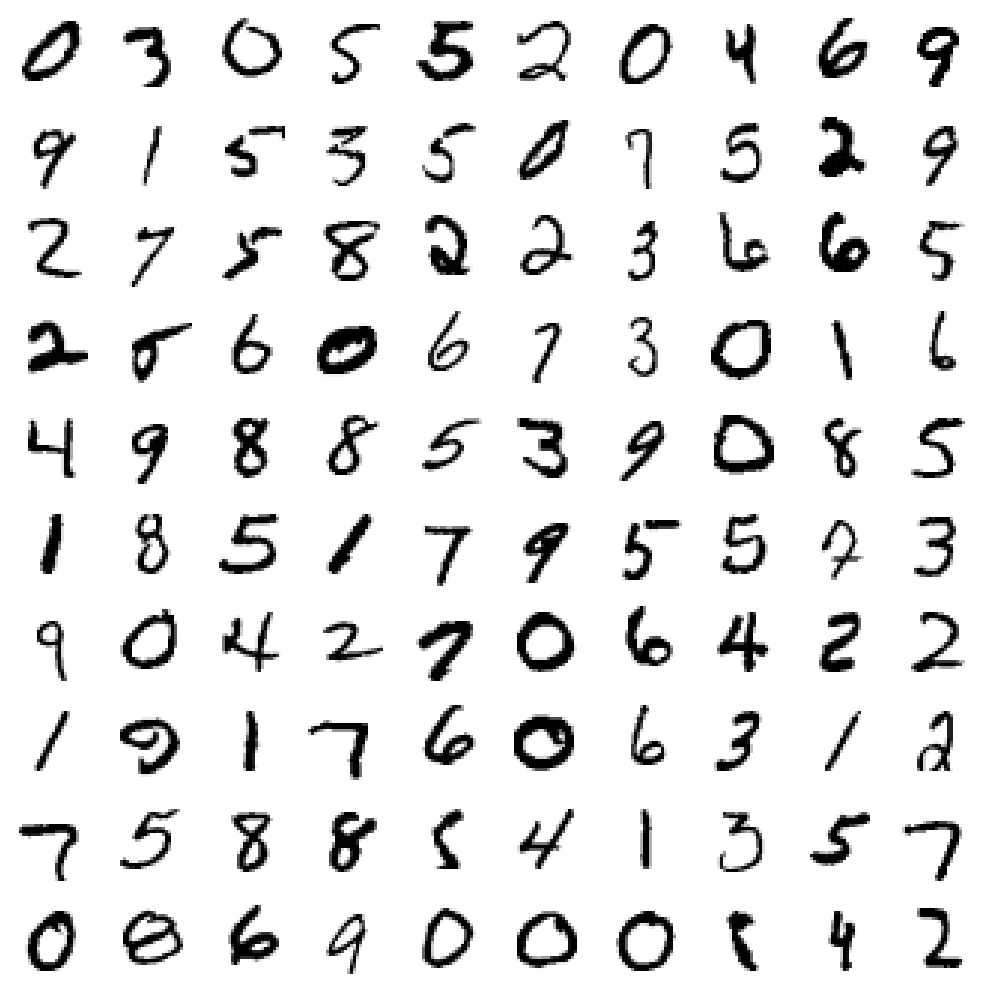

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.utils import to_categorical

# load the MNIST the dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# scale the image intensities to the 0-1 range
x_train = (x_train / 255.0).astype(np.float32)
x_test = (x_test / 255.0).astype(np.float32)

# convert the data to channel-last
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# convert the labels to one-hot encoded
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

def plot_images(images, dim=(10, 10), figsize=(10, 10), title=''):
    
    plt.figure(figsize=figsize)
    
    for i in range(images.shape[0]):
        plt.subplot(dim[0], dim[1], i+1)
        plt.imshow(images[i], interpolation='nearest', cmap='gray_r')
        plt.axis('off')
    
    plt.tight_layout()
    plt.suptitle(title)
    plt.show()
    
plot_images(x_train[np.random.randint(0, x_train.shape[0], size=100)].reshape(100, 28, 28))

The MNIST classification task is quite simple: given an image, predict the digit that it contains. Thus, this is a 10-class classification problem.

Let's define a simple network for the handwritten digit classification.

In [2]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense

model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 64)        18496     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 12, 12, 64)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 12, 12, 64)        0         
                                                                 
 flatten (Flatten)           (None, 9216)              0         
                                                                 
 dense (Dense)               (None, 128)               1179776   
                                                        

Compile and train the network (note that this could take a while).

In [3]:
from keras.losses import categorical_crossentropy
from keras.optimizers import Adam

model.compile(loss=categorical_crossentropy, optimizer=Adam(), metrics=['accuracy'])

model.fit(x_train, y_train,
          batch_size=128,
          epochs=12,
          verbose=1,
          validation_data=(x_test, y_test))

score = model.evaluate(x_test, y_test, verbose=0)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

Epoch 1/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8463 - loss: 0.4856 - val_accuracy: 0.9813 - val_loss: 0.0581
Epoch 2/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9737 - loss: 0.0898 - val_accuracy: 0.9867 - val_loss: 0.0408
Epoch 3/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9810 - loss: 0.0660 - val_accuracy: 0.9888 - val_loss: 0.0323
Epoch 4/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9844 - loss: 0.0508 - val_accuracy: 0.9895 - val_loss: 0.0312
Epoch 5/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9861 - loss: 0.0452 - val_accuracy: 0.9892 - val_loss: 0.0311
Epoch 6/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9878 - loss: 0.0406 - val_accuracy: 0.9903 - val_loss: 0.0288
Epoch 7/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9897 - loss: 0.0330 - val_accuracy: 0.9915 - val_loss: 0.0270
Epoch 8/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9917 - loss: 0.0303 - val_accu

Now that the model is trained, we can evaluate its performance on the independent test dataset.

In [4]:
score = model.evaluate(x_test, y_test, verbose=0)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.034723132848739624
Test accuracy: 0.9914000034332275


## U-Net
The U-Net convolutional neural network architecture was first developed for biomedical image segmentation and is to this day one of the most widely used methods for image segmentation. The details of the architecture can be found in the [original paper](https://arxiv.org/abs/1505.04597). In this practical we will build and train a U-Net network that is able to segment blood vessels in retinal images. 

### Loading and visualizing the data
The data for this task is taken from the [DRIVE](https://www.kaggle.com/datasets/andrewmvd/drive-digital-retinal-images-for-vessel-extraction) database. It consists of photographs of the retina, where the goal is to segment the blood vessels within. The dataset has a total of 40 photographs, divided in 20 images for training and 20 for testing. The images corresponding to the DRIVE test set can be found [here](https://drive.google.com/file/d/1Enau6gb_BtPKCg1Yt5MZIIM18pfVEhxQ/view?usp=sharing).

Let's load the training set and visualize an image with the corresponding blood vessel segmentation. For training we will divide the data in a training and a validation set to monitor the model during training.

In [ ]:
pip install git+https://github.com/tueimage/gryds.git

Note: you may need to restart the kernel to use updated packages.Collecting git+https://github.com/tueimage/gryds.git
  Cloning https://github.com/tueimage/gryds.git to c:\users\rozhan moosavi\appdata\local\temp\pip-req-build-guaaggei
  Resolved https://github.com/tueimage/gryds.git to commit cda4bac8f71e8bb47fc632b8cdea010904ae5cf1
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for gryds: filename=gryds-0.0.1-py3-none-any.whl size=45783 sha256=3c2ef73f2bfaab7e2747b77cdb17208378fd7f71170cf0244b29d1528a6a7332
  Stored in directory: C:\Users\Rozhan Moosavi\AppData\Local\Temp\pip-ephem-wheel-cache-hyyfym4y\wheels\b2\49\57\1c86db6ea25a58d11f959b3fb241d8141b7b4b34db3506fce3
Successfully built gryds



  Running command git clone --filter=blob:none --quiet https://github.com/tueimage/gryds.git 'C:\Users\Rozhan Moosavi\AppData\Local\Temp\pip-req-build-guaaggei'
  DEPRECATION: Building 'gryds' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'gryds'. Discussion can be found at https://github.com/pypa/pip/issues/6334

[notice] A new release of pip is available: 25.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


['D:\\university\\Q1\\ML in bio\\Practicals\\DRIVE\\training\\images\\21_training.tif', 'D:\\university\\Q1\\ML in bio\\Practicals\\DRIVE\\training\\images\\22_training.tif', 'D:\\university\\Q1\\ML in bio\\Practicals\\DRIVE\\training\\images\\23_training.tif', 'D:\\university\\Q1\\ML in bio\\Practicals\\DRIVE\\training\\images\\24_training.tif', 'D:\\university\\Q1\\ML in bio\\Practicals\\DRIVE\\training\\images\\25_training.tif', 'D:\\university\\Q1\\ML in bio\\Practicals\\DRIVE\\training\\images\\26_training.tif', 'D:\\university\\Q1\\ML in bio\\Practicals\\DRIVE\\training\\images\\27_training.tif', 'D:\\university\\Q1\\ML in bio\\Practicals\\DRIVE\\training\\images\\28_training.tif', 'D:\\university\\Q1\\ML in bio\\Practicals\\DRIVE\\training\\images\\29_training.tif', 'D:\\university\\Q1\\ML in bio\\Practicals\\DRIVE\\training\\images\\30_training.tif', 'D:\\university\\Q1\\ML in bio\\Practicals\\DRIVE\\training\\images\\31_training.tif', 'D:\\university\\Q1\\ML in bio\\Practicals

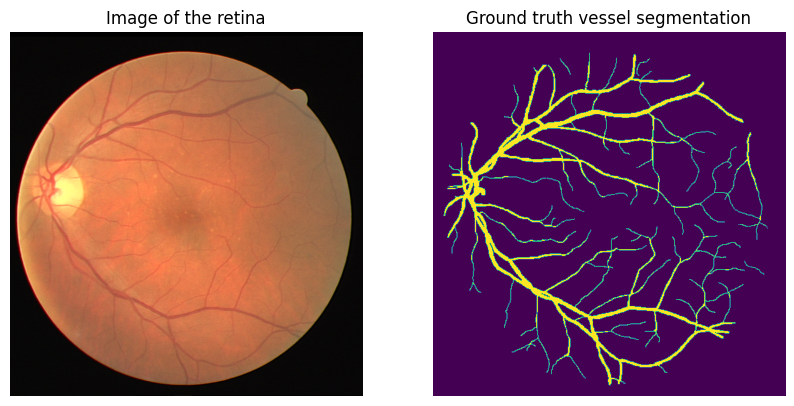

(16, 584, 565, 3)
(16, 584, 565, 1)
(16, 584, 565, 1)
(4, 584, 565, 3)
(4, 584, 565, 1)
(4, 584, 565, 1)


In [5]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from glob import glob
from unet_utils import load_data

# location of the DRIVE dataset
train_paths = glob(r'D:\university\Q1\ML in bio\Practicals\DRIVE\training\images\*.tif')
# data_folder = r'D:\university\Q1\ML in bio\Practicals\DRIVE'
# train_paths = glob(data_folder + 'training\images\*.tif')
images, masks, segmentations = load_data(train_paths)

print(train_paths)

# print the shape of image dataset
print(images.shape)

plt.figure(figsize=(10, 8))

plt.subplot(1, 2, 1)
plt.title("Image of the retina")
plt.axis('off')
plt.imshow(images[0])

plt.subplot(1, 2, 2)
plt.title("Ground truth vessel segmentation")
plt.axis('off')
plt.imshow(segmentations[0][:, :, 0])

plt.show()

# divide in training and validation
train_images, val_images, train_masks, val_masks, train_segmentations, val_segmentations = train_test_split(
    images, masks, segmentations, test_size=0.2, random_state=7)

# print the shape of the training and valudation datasets
print(train_images.shape)
print(train_masks.shape)
print(train_segmentations.shape)
print(val_images.shape)
print(val_masks.shape)
print(val_segmentations.shape)

### Training a U-Net model

You are already provided with implementation of the U-Net architecture in `unet_model.py`. This is a modular implementation and can be used to generate U-Net architectures with a variety of hyperparameters such as depth and number of feature maps. Before using the model, examine the code and documentation and make sure that you understand all the details.

We will train a U-Net model using smaller patches extracted from the training images. Training the images on smaller patches requires less computation power and results in a more varied training dataset (it has the effect of data augmentation by image translation). Because a U-Net is a fully convolutional network it can be evaluated on inputs of different size (the output size will change according to the input size). Thus, although the model will be trained on smaller patches it can still be used to segment larger images with one pass through the model. 


(16, 32, 32, 3)


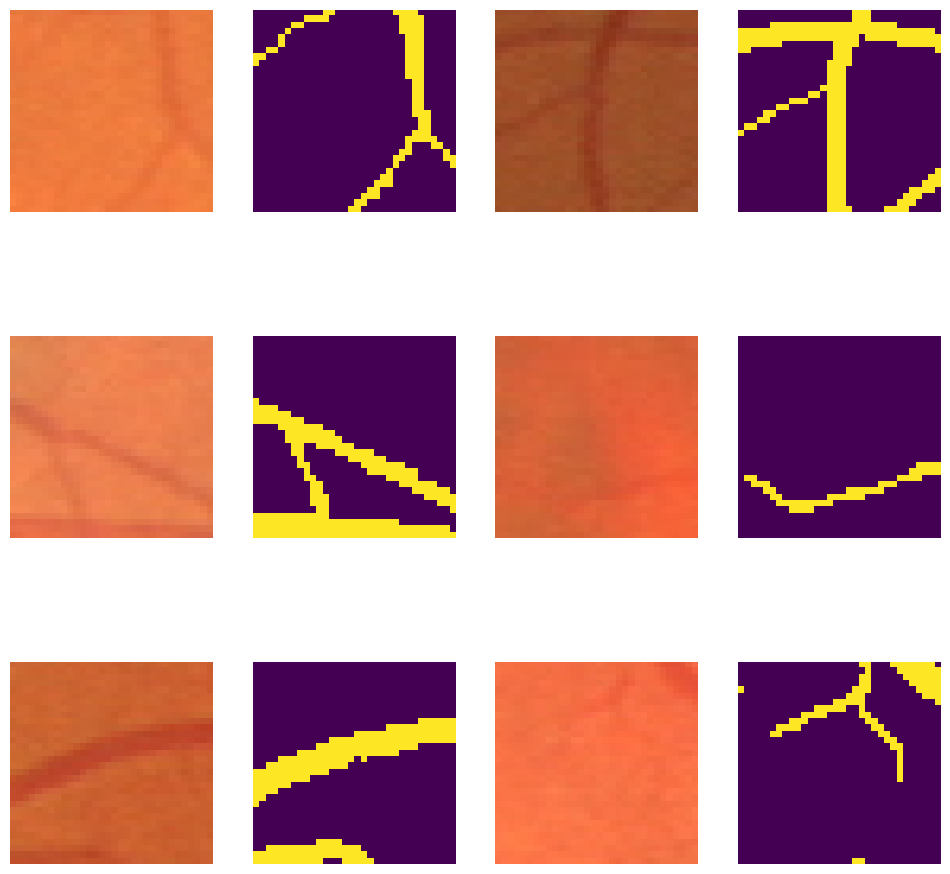

In [6]:
from unet_utils import extract_patches, preprocessing

# work with 32x32 patches
patch_size = (32, 32)

# 200 patches per image
patches_per_im = 200

# visualize a couple of patches as a visual check
patches, patches_segmentations = extract_patches(train_images, train_segmentations, patch_size, patches_per_im=1, seed=7)

print(patches.shape)

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(12, 12))

for i in range(0, 3):
    axes[i, 0].axis('off')
    axes[i, 0].imshow(patches[i])
    axes[i, 1].axis('off')
    axes[i, 1].imshow(patches_segmentations[i][:, :, 0])
    axes[i, 2].axis('off')
    axes[i, 2].imshow(patches[i+5])
    axes[i, 3].axis('off')
    axes[i, 3].imshow(patches_segmentations[i+5][:, :, 0])

plt.show()

In [7]:
# pad the validation data to fit the U-Net model
# images of shape (584, 565) shape result in concatenation error due to the odd number of columns

print("Old shape:", val_images.shape)

val_images, val_masks, val_segmentations = preprocessing(
    val_images, 
    val_masks, 
    val_segmentations, 
    desired_shape=(584, 584))
    
print("New shape:", val_images.shape)

Old shape: (4, 584, 565, 3)
New shape: (4, 584, 584, 3)


In [33]:
import os
from unet_model import unet
from unet_utils import datagenerator
from keras.models import load_model
from keras.optimizers import Adam, SGD
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# use a single training image, to better demonstrate the effects of data augmentation
X_train, y_train = np.expand_dims(train_images[0], axis=0), np.expand_dims(train_segmentations[0], axis=0)

print(X_train.shape)
print(y_train.shape)

# hyperparameters
depth = 3
channels = 32
use_batchnorm = True
batch_size = 64
epochs = 250
steps_per_epoch = int(np.ceil((patches_per_im * len(train_images)) / batch_size))

# work with 32x32 patches
patch_size = (32, 32)
# 200 patches per image
patches_per_im = 200

# initialize model
model = unet(input_shape=(None, None, 3), depth=depth, channels=channels, batchnorm=use_batchnorm)

# print a summary of the model
# model.summary(line_length=120)

# compile the model
model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])

# stop the training if the validation loss does not increase for 15 consecutive epochs
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# train the model with the data generator, and save the training history
history = model.fit(datagenerator(X_train, y_train, patch_size, patches_per_im, batch_size),
                              validation_data=(val_images, val_segmentations),
                              steps_per_epoch=steps_per_epoch, epochs=epochs, verbose=2,
                              callbacks=[early_stopping])

(1, 584, 565, 3)
(1, 584, 565, 1)
Epoch 1/250
50/50 - 22s - loss: 0.5013 - accuracy: 0.8355 - val_loss: 0.4615 - val_accuracy: 0.9127 - 22s/epoch - 442ms/step
Epoch 2/250
50/50 - 20s - loss: 0.3037 - accuracy: 0.9526 - val_loss: 0.5189 - val_accuracy: 0.8386 - 20s/epoch - 391ms/step
Epoch 3/250
50/50 - 20s - loss: 0.2159 - accuracy: 0.9561 - val_loss: 0.2886 - val_accuracy: 0.9211 - 20s/epoch - 409ms/step
Epoch 4/250
50/50 - 20s - loss: 0.1782 - accuracy: 0.9563 - val_loss: 0.3448 - val_accuracy: 0.9094 - 20s/epoch - 410ms/step
Epoch 5/250
50/50 - 20s - loss: 0.1740 - accuracy: 0.9524 - val_loss: 0.2762 - val_accuracy: 0.9215 - 20s/epoch - 408ms/step
Epoch 6/250
50/50 - 21s - loss: 0.1477 - accuracy: 0.9567 - val_loss: 1.0991 - val_accuracy: 0.9210 - 21s/epoch - 414ms/step
Epoch 7/250
50/50 - 20s - loss: 0.1535 - accuracy: 0.9542 - val_loss: 0.4696 - val_accuracy: 0.9202 - 20s/epoch - 404ms/step
Epoch 8/250
50/50 - 19s - loss: 0.1242 - accuracy: 0.9612 - val_loss: 0.4361 - val_accuracy

### Visualizing the segmentation results

In [4]:
# run the model on one test image and show the results
from unet_utils import preprocessing

# test data paths
# impaths_test = glob(data_folder + 'test/images/*.tif')
impaths_test = glob(r'D:\university\Q1\ML in bio\Practicals\DRIVE\test\images\*.tif')


# load data
test_images, test_masks, test_segmentations = load_data(impaths_test, test=True)
print(impaths_test)


# pad the data to fit the U-Net model
test_images, test_masks, test_segmentations = preprocessing(test_images, test_masks, test_segmentations, 
                                                            desired_shape=(584, 584))

# use a single image to evaluate
X_test, y_test = np.expand_dims(test_images[0], axis=0), np.expand_dims(test_masks[0], axis=0)

# predict test samples
test_prediction = model.predict(X_test, batch_size=4)

# visualize the test result
plt.figure(figsize=(12, 10))

plt.subplot(1, 3, 1)
plt.title("Image of the retina")
plt.axis('off')
plt.imshow(test_images[0])

plt.subplot(1, 3, 2)
plt.title("Ground truth vessel segmentation")
plt.axis('off')
plt.imshow(test_segmentations[0][:, :, 0])

plt.subplot(1, 3, 3)
plt.title("Predicted vessel segmentation")
plt.axis('off')
plt.imshow(test_prediction[0, :, :, 0])

plt.show()

['D:\\university\\Q1\\ML in bio\\Practicals\\DRIVE\\test\\images\\01_test.tif', 'D:\\university\\Q1\\ML in bio\\Practicals\\DRIVE\\test\\images\\02_test.tif', 'D:\\university\\Q1\\ML in bio\\Practicals\\DRIVE\\test\\images\\03_test.tif', 'D:\\university\\Q1\\ML in bio\\Practicals\\DRIVE\\test\\images\\04_test.tif', 'D:\\university\\Q1\\ML in bio\\Practicals\\DRIVE\\test\\images\\05_test.tif', 'D:\\university\\Q1\\ML in bio\\Practicals\\DRIVE\\test\\images\\06_test.tif', 'D:\\university\\Q1\\ML in bio\\Practicals\\DRIVE\\test\\images\\07_test.tif', 'D:\\university\\Q1\\ML in bio\\Practicals\\DRIVE\\test\\images\\08_test.tif', 'D:\\university\\Q1\\ML in bio\\Practicals\\DRIVE\\test\\images\\09_test.tif', 'D:\\university\\Q1\\ML in bio\\Practicals\\DRIVE\\test\\images\\10_test.tif', 'D:\\university\\Q1\\ML in bio\\Practicals\\DRIVE\\test\\images\\11_test.tif', 'D:\\university\\Q1\\ML in bio\\Practicals\\DRIVE\\test\\images\\12_test.tif', 'D:\\university\\Q1\\ML in bio\\Practicals\\DRIVE\\

NameError: name 'model' is not defined

# Exercises

## Number of parameters

The first convolutional layer in the MNIST example has 320 parameters. The first fully connected layer has 1179,776 parameters. What do these parameters correspond to? 

<font color='#770a0a'>What is the general expression for the number of parameters of 1) a convolutional layer and 2) a fully-connected layer?</font>

## Fully-convolutional MNIST model

Modify the model in the MNIST example in such a way that it only contains convolutional layers while keeping the same number of parameters. If you do the modification correctly, the two models will have the same behaviour (i.e. they will represent the same model, only with different implementation). Show this experimentally. 


## U-Net architecture

<font color='#770a0a'> What is the role of the skip connections in the U-Net neural network architecture? Will it be possible to train the exact same architecture with the skip connections omitted? If yes, what would be the expected result? If no, what would be the cause of the error?</font>

 

## Data augmentation

<font color='#770a0a'>Why does data augmentation result in less overfitting? Can data augmentation be applied to the test samples? If yes, towards what goal? If no, what is preventing that?</font>


Implement random brightness augmentation of the image data by adding a random offset to the image intensity before passing them trough the network at training time. Train a model with random brightness augmentation and compare it to the baseline above. 

Implement data augmentation procedure that in addition to brightness augmentation also performs b-spline geometric augmentation using the [`gryds`](https://github.com/tueimage/gryds) package (you can look at the documentation of the package for an example on how to do that). Compare the new model with the baseline and the model that only performs brightness augmentation.



## Number of parameters
The parameters in the first convolutional layer is the filter that moves over the initial input image. The general expression for the number of parameters in a convolutional layers is $(kernel size^2*input channels+1)*output_channels$. The kernel size represents the filter size in this case 3, the input channels represents the ammount of channels as input in this case 1. This is one filter, every filter has an extra bias term which results in the +1 in the above expression. Furthermore every output channel of a convolutional layer has its own filter, in this case there are 32 output channels. Filling this in the general expression we find that that the first layer has $(3^2*1+1)*32 = (9+1)*32 = 10*32 = 320$ parameters.

In a fully connected layer every output value has a parameter for every input value as well as a bias term, therefore every output value has $input size+1$ parameters. Therefore the amount of total parameters in a fully connected layer is $(input size+1)*output size$. In the MNIST example the input size is 9216 and the output size is 128 so $(9216+1)*128 = 1.179.776$ total parameters



## Fully-convolutional MNIST model

In [9]:
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Conv2D(128, (12,12), activation='relu'))
model.add(Dropout(0.5))
model.add(Conv2D(10, (1,1), activation='softmax'))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 1, 1, 128)      │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 1, 1, 10)       │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

## U-Net architecture
Skip connections provide direct connections between the encoder side and the decoder side of U-Net. Through these skip connections spatial details (feature maps) can be passed directly to preserve them, otherwise spatial information would get lost during the downsampling and then upsampling. Information from both the encoding-decoding path is concatenated with the information passed by skip connections. It would be possible to train the exact same architecture without the skip connections, however the capabilities of the model would greatly decrease since the output segmentation will be based on greatly downsampled images resulting in a decreased test accuracy. In addition, skip connections also improve gradient flow in back propagation, causing more stable training. 


## Data augmentation


### overfitting

Overfitting happens when the model memorize the data instead learning its pattern which can be caused when we have a small dataset.

In data augmentation we creat new training samples by applying some transformations on them. By doing that we will increase the effective size of the trainig dataset which will give the model more diverse examples. It will also make the model to learn the invarient features and reduce the chance of the model to memorize the data. which will in the end make the model generalize better to unseen data which will prevent overfitting. 

Augmentation is meant for training data to increase the diversity and make the model be ready to perform well on unseen data. Even though it is possible to do augmentation on test set it can cause alternation to real world data(that is in the test dataset) and giving a misleading evaluation


### Brightness Model

In [40]:
from week4_augmentation import augmentation_brightness

history = model.fit(
    augmentation_brightness(X_train, y_train, patch_size, patches_per_im, batch_size),
    validation_data=(val_images, val_segmentations),
    steps_per_epoch=steps_per_epoch,
    epochs=epochs,
    verbose=2,
    callbacks=[early_stopping]
)


Epoch 1/250
50/50 - 31s - loss: 0.1251 - accuracy: 0.9571 - val_loss: 1.5525 - val_accuracy: 0.6837 - 31s/epoch - 617ms/step
Epoch 2/250
50/50 - 31s - loss: 0.0981 - accuracy: 0.9651 - val_loss: 0.2498 - val_accuracy: 0.9214 - 31s/epoch - 610ms/step
Epoch 3/250
50/50 - 30s - loss: 0.0972 - accuracy: 0.9655 - val_loss: 0.1526 - val_accuracy: 0.9479 - 30s/epoch - 605ms/step
Epoch 4/250
50/50 - 43s - loss: 0.0944 - accuracy: 0.9661 - val_loss: 0.1533 - val_accuracy: 0.9443 - 43s/epoch - 859ms/step
Epoch 5/250
50/50 - 30s - loss: 0.0956 - accuracy: 0.9646 - val_loss: 0.1655 - val_accuracy: 0.9413 - 30s/epoch - 604ms/step
Epoch 6/250
50/50 - 30s - loss: 0.0959 - accuracy: 0.9648 - val_loss: 4.9272 - val_accuracy: 0.6142 - 30s/epoch - 592ms/step
Epoch 7/250
50/50 - 29s - loss: 0.0891 - accuracy: 0.9677 - val_loss: 0.1783 - val_accuracy: 0.9403 - 29s/epoch - 577ms/step
Epoch 8/250
50/50 - 28s - loss: 0.0915 - accuracy: 0.9665 - val_loss: 0.2240 - val_accuracy: 0.9153 - 28s/epoch - 560ms/step


1/1 [==============================] - 1s 752ms/step


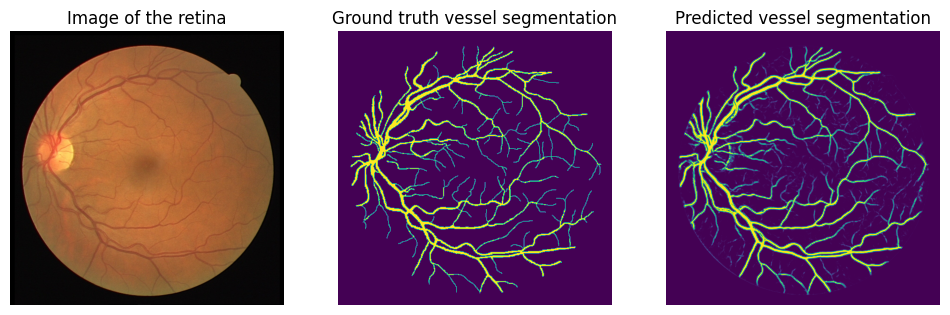

In [41]:
# predict test samples
test_prediction = model.predict(X_test, batch_size=4)

# visualize the test result
plt.figure(figsize=(12, 10))

plt.subplot(1, 3, 1)
plt.title("Image of the retina")
plt.axis('off')
plt.imshow(test_images[0])

plt.subplot(1, 3, 2)
plt.title("Ground truth vessel segmentation")
plt.axis('off')
plt.imshow(test_segmentations[0][:, :, 0])

plt.subplot(1, 3, 3)
plt.title("Predicted vessel segmentation")
plt.axis('off')
plt.imshow(test_prediction[0, :, :, 0])

### GRYDS Model

In [8]:
import os
from unet_model import unet
from unet_utils import datagenerator
from keras.models import load_model
from keras.optimizers import Adam, SGD
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import numpy as np

X_train, y_train = np.expand_dims(train_images[0], axis=0), np.expand_dims(train_segmentations[0], axis=0)

print(X_train.shape)
print(y_train.shape)

# hyperparameters
depth = 3
channels = 32
use_batchnorm = True
batch_size = 64
epochs = 250
steps_per_epoch = int(np.ceil((patches_per_im * len(train_images)) / batch_size))

# work with 32x32 patches
patch_size = (32, 32)
# 200 patches per image
patches_per_im = 200

# initialize model
model = unet(input_shape=(None, None, 3), depth=depth, channels=channels, batchnorm=use_batchnorm)
model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)


(1, 584, 565, 3)
(1, 584, 565, 1)


In [9]:
from week4_augmentation import augmentation_gryds


In [10]:
history = model.fit(
    augmentation_gryds(X_train, y_train, patch_size, patches_per_im, batch_size),
    validation_data=(val_images, val_segmentations),
    steps_per_epoch=int(np.ceil((patches_per_im * len(X_train)) / batch_size)),
    epochs=epochs,
    verbose=2,
    callbacks=[early_stopping]
)



Epoch 1/250
4/4 - 12s - loss: 0.8026 - accuracy: 0.1577 - val_loss: 0.6865 - val_accuracy: 0.7472 - 12s/epoch - 3s/step
Epoch 2/250
4/4 - 11s - loss: 0.7070 - accuracy: 0.1799 - val_loss: 0.6577 - val_accuracy: 0.9211 - 11s/epoch - 3s/step
Epoch 3/250
4/4 - 10s - loss: 0.6785 - accuracy: 0.1775 - val_loss: 0.6350 - val_accuracy: 0.9211 - 10s/epoch - 3s/step
Epoch 4/250
4/4 - 10s - loss: 0.6624 - accuracy: 0.2215 - val_loss: 0.6181 - val_accuracy: 0.9211 - 10s/epoch - 3s/step
Epoch 5/250
4/4 - 5s - loss: 0.6519 - accuracy: 0.2527 - val_loss: 0.6057 - val_accuracy: 0.9211 - 5s/epoch - 1s/step
Epoch 6/250
4/4 - 5s - loss: 0.6391 - accuracy: 0.2725 - val_loss: 0.5882 - val_accuracy: 0.9211 - 5s/epoch - 1s/step
Epoch 7/250
4/4 - 5s - loss: 0.6297 - accuracy: 0.3351 - val_loss: 0.5744 - val_accuracy: 0.9211 - 5s/epoch - 1s/step
Epoch 8/250
4/4 - 5s - loss: 0.6220 - accuracy: 0.2967 - val_loss: 0.5654 - val_accuracy: 0.9211 - 5s/epoch - 1s/step
Epoch 9/250
4/4 - 5s - loss: 0.6094 - accuracy: 

1/1 [==============================] - 1s 816ms/step


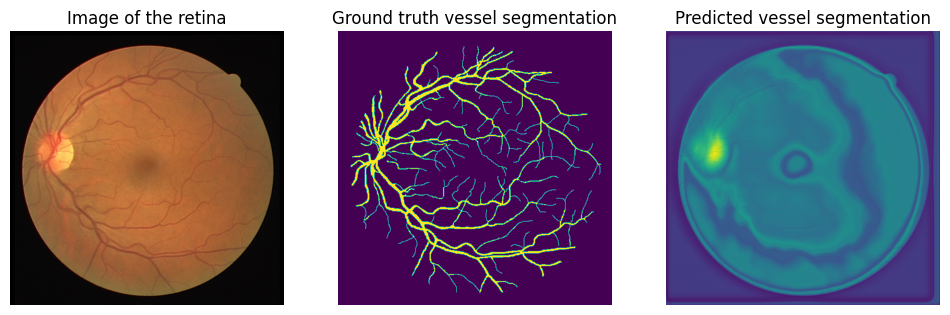

In [11]:
# predict test samples
test_prediction = model.predict(X_test, batch_size=4)

# visualize the test result
plt.figure(figsize=(12, 10))

plt.subplot(1, 3, 1)
plt.title("Image of the retina")
plt.axis('off')
plt.imshow(test_images[0])

plt.subplot(1, 3, 2)
plt.title("Ground truth vessel segmentation")
plt.axis('off')
plt.imshow(test_segmentations[0][:, :, 0])

plt.subplot(1, 3, 3)
plt.title("Predicted vessel segmentation")
plt.axis('off')
plt.imshow(test_prediction[0, :, :, 0])

### comparison 

The GRYDS model with both B-spline and brightness augmentation introduces a complicated geometric and brightness transformations, which can potentially improve model robustness. However, the training accuracy remains low (30–37%) and validation accuracy, while initially high (0.92), becomes extremely unstable after many epochs, with sharp spikes in validation loss. This indicates that the augmentation is currently too strong, producing unrealistic patches that the model struggles to learn from, leading to convergence issues and poor stability.

In contrast, the baseline model without augmentation converges quickly, reaching very high training accuracy (0.95–0.97), with validation accuracy around 0.91–0.92. While training is stable, overfitting is a possibility, as seen in occasional spikes in validation loss. The brightness model offers a middle ground: it maintains high training accuracy similar to the baseline, with validation accuracy consistently around 0.92–0.95. It stabilizes training compared to GRYDS by applying only brightness augmentation, avoiding extreme distortions. Overall, brightness-only is the most stable and GRYDS has potential for robustness but needs gentler augmentations and more future work on it for reliable training.